# EDA Dengue en Colombia — Caquetá
# Autora: Kelly_Valentina
# Dataset: INS / datos.gov.co

In [41]:
import pandas as pd

df = pd.read_csv('../data/data_dengue.csv')
df.head()

,ID,CODIGO EVENTO,AÑO REPORTE,MES REPORTE,SEMANA EPIDEMIOLÓGICA,EDAD,UNI_MED,NACIONALIDAD,SEXO,REGIMEN DE SALUD,PERTENECIA ETNICA,NOM UPGD,NOMBRE DEL EVENTO,PAIS REPORTE,DEPARTAMENTO REPORTE,MUNICIPIO REPORTE
0,279,210,"2,019",ABRIL,17,16,AÑOS,COLOMBIA,FEMENINO,SUBSIDIADO,SIN PERTENENCIA ÉTNICA,SIN DATO,DENGUE,COLOMBIA,CAQUETÁ,PUERTO RICO
1,1,210,"2,018",ENERO,1,34,AÑOS,COLOMBIA,FEMENINO,SUBSIDIADO,SIN PERTENENCIA ÉTNICA,CLINICA MEDILASER SA,DENGUE,COLOMBIA,CAQUETÁ,FLORENCIA
2,2,210,"2,018",ENERO,1,28,AÑOS,COLOMBIA,MASCULINO,SUBSIDIADO,SIN PERTENENCIA ÉTNICA,ESE HOSPITAL COMUNAL LAS MALVINAS,DENGUE,COLOMBIA,CAQUETÁ,FLORENCIA
3,3,210,"2,018",ENERO,2,20,AÑOS,COLOMBIA,FEMENINO,SUBSIDIADO,SIN PERTENENCIA ÉTNICA,ESE HOSPITAL SAN RAFAEL,DENGUE,COLOMBIA,CAQUETÁ,SAN VICENTE DEL CAGUÁN
4,4,210,"2,018",ENERO,2,1,AÑOS,COLOMBIA,FEMENINO,CONTRIBUTIVO,SIN PERTENENCIA ÉTNICA,CLINICA MEDILASER SA,DENGUE,COLOMBIA,CAQUETÁ,SAN VICENTE DEL CAGUÁN


In [42]:
print(df.shape)
print(df.columns.tolist())
df.info()

(6808, 16)
['ID', 'CODIGO EVENTO', 'AÑO REPORTE', 'MES REPORTE', 'SEMANA EPIDEMIOLÓGICA', 'EDAD', 'UNI_MED', 'NACIONALIDAD', 'SEXO', 'REGIMEN DE SALUD', 'PERTENECIA ETNICA', 'NOM UPGD', 'NOMBRE DEL EVENTO', 'PAIS REPORTE', 'DEPARTAMENTO REPORTE', 'MUNICIPIO REPORTE']
<class 'pandas.DataFrame'>
RangeIndex: 6808 entries, 0 to 6807
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   ID                     6808 non-null   str  
 1   CODIGO EVENTO          6808 non-null   int64
 2   AÑO REPORTE            6808 non-null   str  
 3   MES REPORTE            6808 non-null   str  
 4   SEMANA EPIDEMIOLÓGICA  6808 non-null   int64
 5   EDAD                   6808 non-null   int64
 6   UNI_MED                6808 non-null   str  
 7   NACIONALIDAD           6808 non-null   str  
 8   SEXO                   6808 non-null   str  
 9   REGIMEN DE SALUD       6808 non-null   str  
 10  PERTENECIA ETNICA      6808 non

In [43]:
# Limpiar AÑO REPORTE: quitar comas y convertir a entero
df['AÑO REPORTE'] = df['AÑO REPORTE'].str.replace(',', '').astype(int)

# Verificar
print(df['AÑO REPORTE'].unique())
print(df['MES REPORTE'].unique())
print(df['MUNICIPIO REPORTE'].unique())

[2019 2018 2021 2020 2022 2023]
<StringArray>
[     'ABRIL',      'ENERO',    'FEBRERO',      'MARZO',       'MAYO',
      'JUNIO',      'JULIO',     'AGOSTO', 'SEPTIEMBRE',    'OCTUBRE',
  'NOVIEMBRE',  'DICIEMBRE']
Length: 12, dtype: str
<StringArray>
[                   'PUERTO RICO',                      'FLORENCIA',
         'SAN VICENTE DEL CAGUÁN', 'CAQUETA. MUNICIPIO DESCONOCIDO',
           'CARTAGENA DEL CHAIRÁ',                      'EL PAUJIL',
                         'SOLANO',                        'CURILLO',
            'SAN JOSÉ DEL FRAGUA',                        'MORELIA',
                         'SOLITA',         'BELÉN DE LOS ANDAQUIES',
                   'LA MONTANITA',                    'EL DONCELLO',
                        'ALBANIA',                     'VALPARAÍSO',
                          'MILÁN']
Length: 17, dtype: str


In [44]:
# Convertir mes a número para poder ordenar cronológicamente
meses = {
    'ENERO': 1, 'FEBRERO': 2, 'MARZO': 3, 'ABRIL': 4,
    'MAYO': 5, 'JUNIO': 6, 'JULIO': 7, 'AGOSTO': 8,
    'SEPTIEMBRE': 9, 'OCTUBRE': 10, 'NOVIEMBRE': 11, 'DICIEMBRE': 12
}

df['MES_NUM'] = df['MES REPORTE'].map(meses)

# Verificacion
df[['MES REPORTE', 'MES_NUM']].drop_duplicates().sort_values('MES_NUM')

,MES REPORTE,MES_NUM
1,ENERO,1
13,FEBRERO,2
30,MARZO,3
0,ABRIL,4
61,MAYO,5
78,JUNIO,6
101,JULIO,7
124,AGOSTO,8
134,SEPTIEMBRE,9
139,OCTUBRE,10


In [45]:
df.to_csv('../data/data_dengue_limpio.csv', index=False)
print(" Dataset limpio guardado")

 Dataset limpio guardado


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general de las gráficas
sns.set_theme(style="whitegrid")

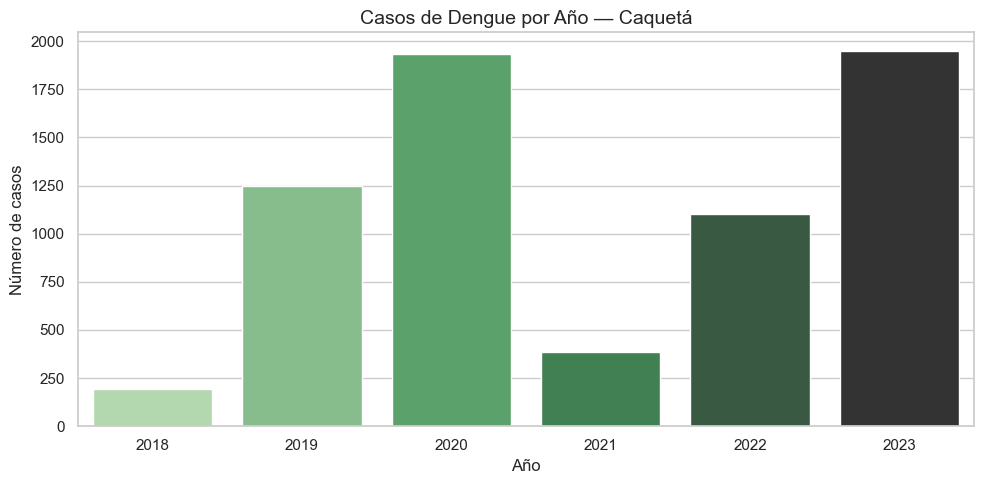

In [47]:
# Casos por año
casos_por_anio = df['AÑO REPORTE'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=casos_por_anio.index, y=casos_por_anio.values,
            hue=casos_por_anio.index, palette='Greens_d', legend=False)
plt.title('Casos de Dengue por Año — Caquetá', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Número de casos')
plt.tight_layout()
plt.savefig('../outputs/casos_por_anio.png')
plt.show()

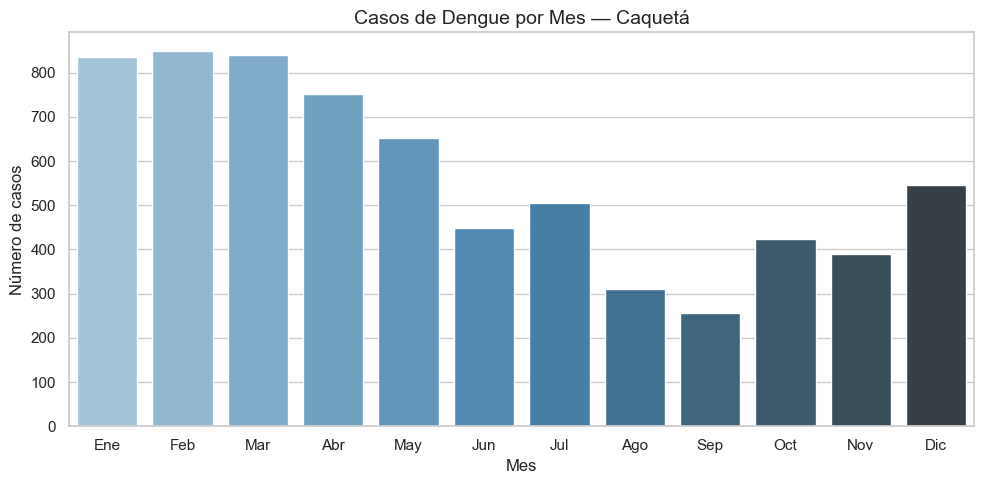

In [48]:
# Casos por mes
casos_por_mes = df.groupby('MES_NUM')['MES REPORTE'].count()
meses_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

plt.figure(figsize=(10, 5))
sns.barplot(x=meses_labels, y=casos_por_mes.values,
            hue=meses_labels, palette='Blues_d', legend=False)
plt.title('Casos de Dengue por Mes — Caquetá', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Número de casos')
plt.tight_layout()
plt.savefig('../outputs/casos_por_mes.png')
plt.show()


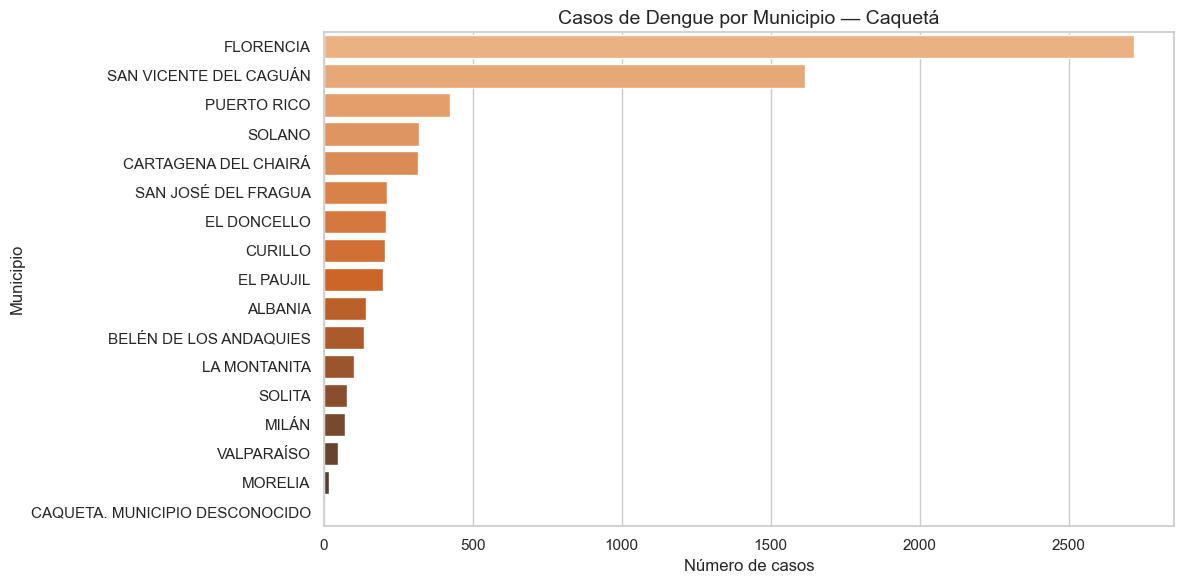

In [49]:
# Casos por municipio
casos_por_municipio = df['MUNICIPIO REPORTE'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=casos_por_municipio.values, y=casos_por_municipio.index,
            hue=casos_por_municipio.index, palette='Oranges_d', legend=False)
plt.title('Casos de Dengue por Municipio — Caquetá', fontsize=14)
plt.xlabel('Número de casos')
plt.ylabel('Municipio')
plt.tight_layout()
plt.savefig('../outputs/casos_por_municipio.png')
plt.show()

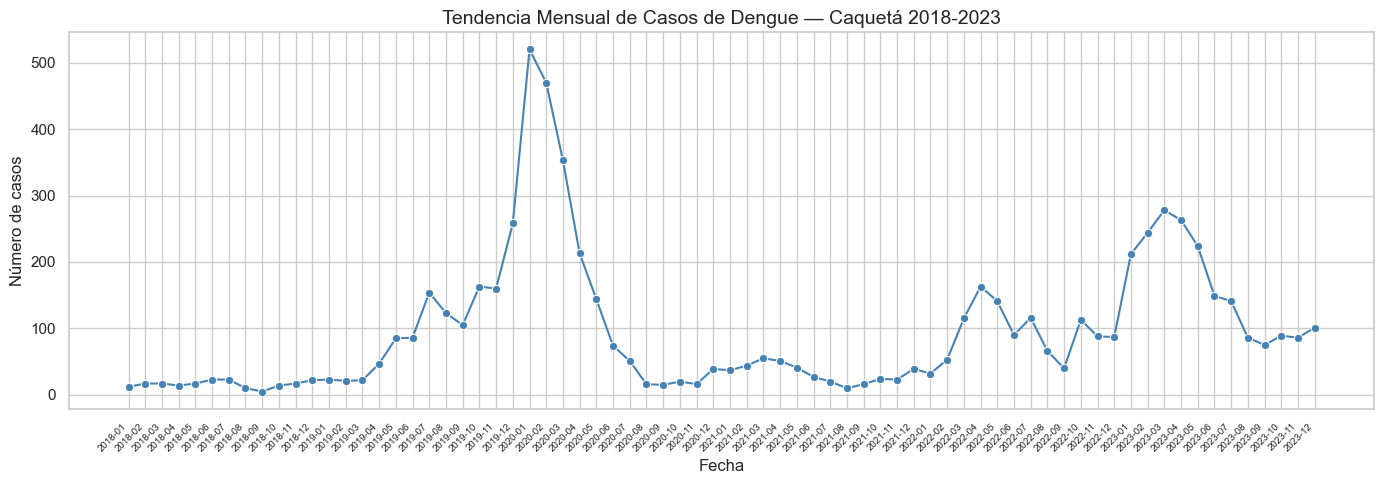

In [50]:
# Tendencia mensual a lo largo del tiempo
tendencia = df.groupby(['AÑO REPORTE', 'MES_NUM']).size().reset_index(name='casos')
tendencia['fecha'] = tendencia['AÑO REPORTE'].astype(str) + '-' + tendencia['MES_NUM'].astype(str).str.zfill(2)
tendencia = tendencia.sort_values(['AÑO REPORTE', 'MES_NUM'])

plt.figure(figsize=(14, 5))
sns.lineplot(data=tendencia, x='fecha', y='casos', marker='o', color='steelblue')
plt.title('Tendencia Mensual de Casos de Dengue — Caquetá 2018-2023', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Número de casos')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig('../outputs/tendencia_mensual.png')
plt.show()


## Introducción

Este análisis exploratorio estudia los casos de dengue reportados 
en el departamento de Caquetá, Colombia, entre 2018 y 2023.

**Fuente de datos:** datos.gov.co — Instituto Nacional de Salud (INS)  
**Total de registros:** 6.808 casos  
**Municipios analizados:** 17

## Hallazgos Principales

### Comportamiento temporal
- El **2020** y el **2023** fueron los años con mayor número de casos.
- **Febrero** es el mes con más casos reportados, coincidiendo con 
  el final de la temporada de lluvias en la Amazonía.

### Distribución geográfica
- **Florencia**, como capital departamental y ciudad más poblada, 
  concentra la mayor cantidad de casos.
- Se registraron casos en los **17 municipios** del departamento.

### Tendencia
- Los casos muestran picos cíclicos a lo largo de los años, 
  con variaciones estacionales marcadas.

## Conclusiones

1. **Estacionalidad clara:** el dengue en Caquetá tiene un patrón 
   estacional marcado, con picos a principios de año (febrero), 
   relacionado con la temporada de lluvias.

2. **Años críticos:** el aumento en 2020 pudo estar influenciado 
   por la pandemia COVID-19, que afectó los sistemas de reporte. 
   El pico de 2023 coincide con el fenómeno de El Niño, que genera 
   condiciones favorables para el mosquito Aedes aegypti.

3. **Concentración urbana:** Florencia concentra la mayoría de casos 
   por ser el centro poblado más grande, lo que sugiere que las 
   intervenciones de salud pública deben priorizarse en zonas urbanas.

4. **Cobertura completa:** los 17 municipios del departamento tienen 
   registros, lo que indica un sistema de vigilancia activo.

## Limitaciones

- Los datos corresponden únicamente al departamento de **Caquetá** 
  y no permiten comparaciones con otros departamentos.
- No se incluyeron variables climáticas (temperatura, precipitación) 
  que permitirían confirmar la relación con la estacionalidad.
- El dataset no distingue entre **dengue clásico** y **dengue grave**, 
  lo que limita el análisis de severidad.
- Los casos con municipio **"desconocido"** no pudieron ser 
  asignados geográficamente.
